Saving archive (1).zip to archive (1).zip
Dataset extracted successfully
Dataset loaded successfully
                 track_id                                         track_name  \
0  6f807x0ima9a1j3VPbc7VN  I Don't Care (with Justin Bieber) - Loud Luxur...   
1  0r7CVbZTWZgbTCYdfa2P31                    Memories - Dillon Francis Remix   
2  1z1Hg7Vb0AhHDiEmnDE79l                    All the Time - Don Diablo Remix   
3  75FpbthrwQmzHlBJLuGdC7                  Call You Mine - Keanu Silva Remix   
4  1e8PAfcKUYoKkxPhrHqw4x            Someone You Loved - Future Humans Remix   

       track_artist  track_popularity          track_album_id  \
0        Ed Sheeran                66  2oCs0DGTsRO98Gh5ZSl2Cx   
1          Maroon 5                67  63rPSO264uRjW1X5E6cWv6   
2      Zara Larsson                70  1HoSmj2eLcsrR0vE9gThr4   
3  The Chainsmokers                60  1nqYsOef1yKKuGOVchbsk6   
4     Lewis Capaldi                69  7m7vv9wlQ4i0LFuJiE2zsQ   

                           

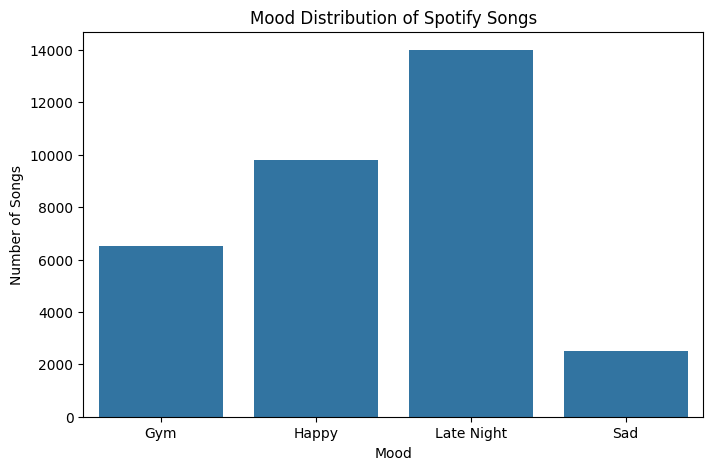

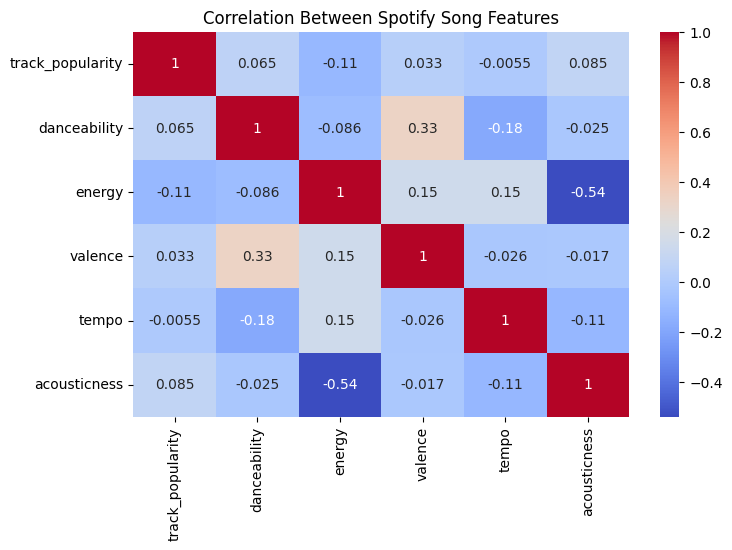

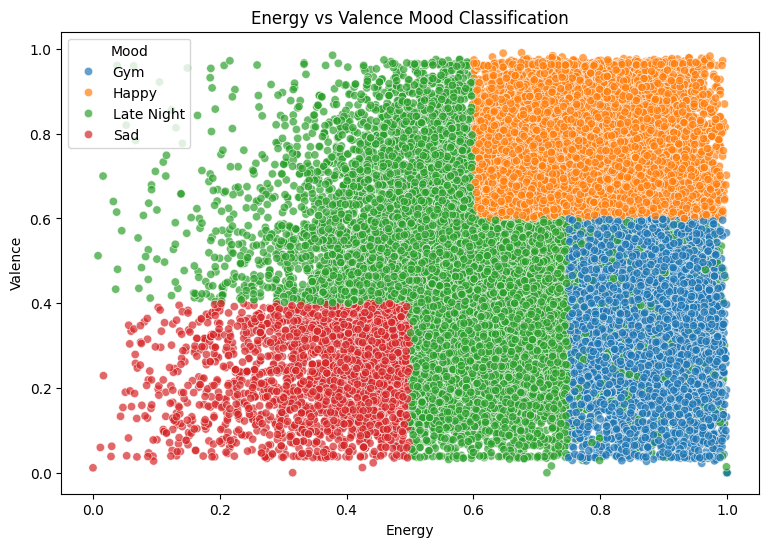

Average values by mood:
            danceability    energy   valence       tempo  track_popularity
Mood                                                                      
Gym             0.591897  0.871785  0.354809  134.652591         36.682567
Happy           0.700259  0.786373  0.762007  121.279133         42.782024
Late Night      0.662781  0.616088  0.455819  115.244270         44.379438
Sad             0.596312  0.368374  0.236980  115.154750         45.752680
Probability of Happy song: 0.3
Probability of Sad song: 0.08
Probability of Gym song: 0.2
Probability of Late Night song: 0.43
Correlation between Energy and Valence: 0.151
P-value: 8.79333591182265e-167
Result: Energy and Valence have a statistically significant relationship
T-statistic: 183.016
P-value: 0.0
Result: Happy songs and Sad songs have different average energy levels
Top Happy Songs:
                      track_name         track_artist  track_popularity
19264            Don't Start Now             Dua Lipa  

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [1]:
# Spotify Mood Analysis Project
# Can Your Spotify Predict Your Mood?

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, ttest_ind
from google.colab import files
import zipfile
import os


uploaded = files.upload()

zip_file_name = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
    zip_ref.extractall("spotify_data")

print("Dataset extracted successfully")

df = pd.read_csv("spotify_songs.csv")

print("Dataset loaded successfully")
print(df.head())

print("Shape of dataset:", df.shape)
print(df.info())
print(df.isnull().sum())

df = df[
    [
        "track_name",
        "track_artist",
        "track_popularity",
        "playlist_genre",
        "danceability",
        "energy",
        "valence",
        "tempo",
        "acousticness"
    ]
]

df = df.dropna()

def find_mood(row):
    if row["valence"] >= 0.60 and row["energy"] >= 0.60:
        return "Happy"
    elif row["valence"] < 0.40 and row["energy"] < 0.50:
        return "Sad"
    elif row["energy"] >= 0.75 and row["tempo"] >= 110:
        return "Gym"
    else:
        return "Late Night"

df["Mood"] = df.apply(find_mood, axis=1)


print(df["Mood"].value_counts())


df.to_csv("spotify_mood_cleaned.csv", index=False)

plt.figure(figsize=(8, 5))
sns.countplot(x="Mood", data=df)
plt.title("Mood Distribution of Spotify Songs")
plt.xlabel("Mood")
plt.ylabel("Number of Songs")
plt.show()


plt.figure(figsize=(8, 5))
sns.heatmap(
    df[["track_popularity", "danceability", "energy", "valence", "tempo", "acousticness"]].corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Between Spotify Song Features")
plt.show()


plt.figure(figsize=(9, 6))
sns.scatterplot(
    x="energy",
    y="valence",
    hue="Mood",
    data=df,
    alpha=0.7
)
plt.title("Energy vs Valence Mood Classification")
plt.xlabel("Energy")
plt.ylabel("Valence")
plt.show()


mood_summary = df.groupby("Mood")[["danceability", "energy", "valence", "tempo", "track_popularity"]].mean()

print("Average values by mood:")
print(mood_summary)


total_songs = len(df)

happy_songs = len(df[df["Mood"] == "Happy"])
sad_songs = len(df[df["Mood"] == "Sad"])
gym_songs = len(df[df["Mood"] == "Gym"])
late_night_songs = len(df[df["Mood"] == "Late Night"])

print("Probability of Happy song:", round(happy_songs / total_songs, 2))
print("Probability of Sad song:", round(sad_songs / total_songs, 2))
print("Probability of Gym song:", round(gym_songs / total_songs, 2))
print("Probability of Late Night song:", round(late_night_songs / total_songs, 2))


corr_value, p_value = pearsonr(df["energy"], df["valence"])

print("Correlation between Energy and Valence:", round(corr_value, 3))
print("P-value:", p_value)

if p_value < 0.05:
    print("Result: Energy and Valence have a statistically significant relationship")
else:
    print("Result: Energy and Valence do not have a statistically significant relationship")


happy_energy = df[df["Mood"] == "Happy"]["energy"]
sad_energy = df[df["Mood"] == "Sad"]["energy"]

t_stat, p_val = ttest_ind(happy_energy, sad_energy, equal_var=False)

print("T-statistic:", round(t_stat, 3))
print("P-value:", p_val)

if p_val < 0.05:
    print("Result: Happy songs and Sad songs have different average energy levels")
else:
    print("Result: No major difference found in energy levels")


print("Top Happy Songs:")
print(df[df["Mood"] == "Happy"][["track_name", "track_artist", "track_popularity"]].sort_values(by="track_popularity", ascending=False).head(10))

print("Top Sad Songs:")
print(df[df["Mood"] == "Sad"][["track_name", "track_artist", "track_popularity"]].sort_values(by="track_popularity", ascending=False).head(10))

print("Top Gym Songs:")
print(df[df["Mood"] == "Gym"][["track_name", "track_artist", "track_popularity"]].sort_values(by="track_popularity", ascending=False).head(10))

print("Top Late Night Songs:")
print(df[df["Mood"] == "Late Night"][["track_name", "track_artist", "track_popularity"]].sort_values(by="track_popularity", ascending=False).head(10))


user_mood = input("Enter your mood: Happy, Sad, Gym, or Late Night: ")

recommended_songs = df[df["Mood"].str.lower() == user_mood.lower()]

if len(recommended_songs) > 0:
    print("Recommended songs for your mood:")
    print(recommended_songs[["track_name", "track_artist", "track_popularity"]].sample(10))
else:
    print("Mood not found. Please enter Happy, Sad, Gym, or Late Night.")


files.download("spotify_mood_cleaned.csv")